# Ginkgo Inference Example

This notebook compares Ginkgo truth samples to Trellis likelihood surfaces, estimates the best-fit splitting parameter, and then checks whether reweighting improves agreement with observables.

Workflow:
1. Load the truth jet trees and the precomputed Trellis likelihood grids.
2. Remove invalid jets with non-finite likelihood values.
3. Find the maximum-likelihood estimate in the scanned $\lambda$ range.
4. Regenerate a reference sample at the MLE point and recompute the likelihood surface.
5. Reweight the truth sample and compare basic observables.

In [1]:
import numpy as np
import os
import pickle
import time

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

## Setup

Import the analysis dependencies used throughout the notebook.

In [ ]:
def load_jets(root_dir, filename):
    """Load a pickled jet-tree dataset from <root_dir>/<filename>.pkl."""
    filename = os.path.join(root_dir, filename)
    with open(filename + ".pkl", "rb") as fd:
        truth = pickle.load(fd, encoding='latin-1')
    return truth

## Load the truth sample

The truth sample is stored as a pickle file containing the generated binary trees.

In [3]:
lambda_truth = 2.4
pt_cut_truth = 30.0

n_lambda = 150
Njets = 10000

#lambda_min = 1.6
#lambda_max = 2.75

lambda_min = 1.9
lambda_max = 3.05

lambda_vals = np.linspace(lambda_min, lambda_max, n_lambda)

# Njets = 100000

## Define the scan range

Set the truth parameter values and the scan grid in $\lambda$.

In [4]:
truth_bin = None
        
for ix, x in enumerate(lambda_vals >= lambda_truth):
    if x.item() is True:
        truth_bin = ix-1
        break

## Locate the truth bin

Identify which grid point contains the truth value of $\lambda$.

In [5]:
gt_trees = load_jets("data", "ginkgo_{}_jets_no_cuts_lambda_{}_pt_min_{}_jetp_400_with_perm".format(Njets,
                                                                                                    int(lambda_truth*10),
                                                                                                    int(pt_cut_truth)))  # My test file

## Load the truth trees

Read the comparison sample that matches the truth configuration.

The next block loads the precomputed Trellis likelihood surfaces for every scanned value of $\lambda$ and stacks them into a single array.

## Load Trellis likelihood surfaces

Read the precomputed likelihood grid for each scanned $\lambda$ value.

In [ ]:
def get_likelihood_surface_array(lambda_min, lambda_max, n_lambda,
                                 Njets=10000,
                                 pt_cut=30.0,
                                 likelihood="marginal",
                                 datadir="/mnt/g/ginkgo/trellis"):
    """
    Load the per-jet likelihood surfaces for a scan in $\lambda$.

    The returned array has shape (Njets, n_lambda), where each column contains
    the likelihood values for one scan point.
    """

    if likelihood.lower() == "marginal":
        key = "Z"
    elif likelihood.lower() == "map":
        key = "trellis_MLE"
    else:
        return None

    lambda_vals = np.linspace(lambda_min, lambda_max, n_lambda)

    likelihood_surface = np.zeros((Njets, n_lambda))

    for i in tqdm(range(n_lambda)):
        model_params = {"delta_min": pt_cut, "lam": lambda_vals[i]}
        in_filename = os.path.join(datadir, "trellis_{}_jets_1D_lambda_{:n}_ptcut_{:n}_{}_with_perm.pkl".format(
            Njets,
            int(lambda_vals[i]*1000),
            int(pt_cut),
            i))
        with open(in_filename, "rb") as fd:
            results = pickle.load(fd, encoding='latin-1')

        for k in range(Njets):
            likelihood_surface[k, i] = results[key][k]

    return likelihood_surface

After loading the grid, the notebook checks each jet for non-finite entries and removes those jets before computing totals.

## Filter invalid jets

Remove jets whose likelihood surfaces contain NaN or infinite values before summing over the sample.

In [7]:
# Njets = 100000

datadir = "/mnt/g/ginkgo/trellis"

likelihood_surface_array = get_likelihood_surface_array(lambda_min, lambda_max, n_lambda,
                                                        Njets=Njets,
                                                        pt_cut=pt_cut_truth,
                                                        likelihood="marginal",
                                                        datadir=datadir)

100%|██████████| 150/150 [00:06<00:00, 24.44it/s]


The total log-likelihood surface is formed by summing the per-jet surfaces over the sample.

In [8]:
bad_indices = []
for ix, entry in enumerate(likelihood_surface_array):
    if np.any(np.isnan(entry)) or np.any(np.isinf(entry)):
         bad_indices.append(ix)
    # if np.isnan(entry).sum() == n_lambda:
    #     bad_indices.append(ix)
bad_indices = np.array(bad_indices)
print("Number of bad jets: {:n}".format(len(bad_indices)))
        
good_indices = np.arange(likelihood_surface_array.shape[0])
for bad_ix in bad_indices:
    good_indices = good_indices[good_indices != bad_ix]

Number of bad jets: 4


In [9]:
likelihood_surface_array = likelihood_surface_array[good_indices]
gt_trees = (np.array(gt_trees)[good_indices]).tolist()

The next cell extracts the scan point with the largest total log-likelihood and reports the corresponding $\lambda$ value.

## Estimate the Trellis MLE

Sum the per-jet log-likelihoods over the sample and locate the scan point with the largest total value.

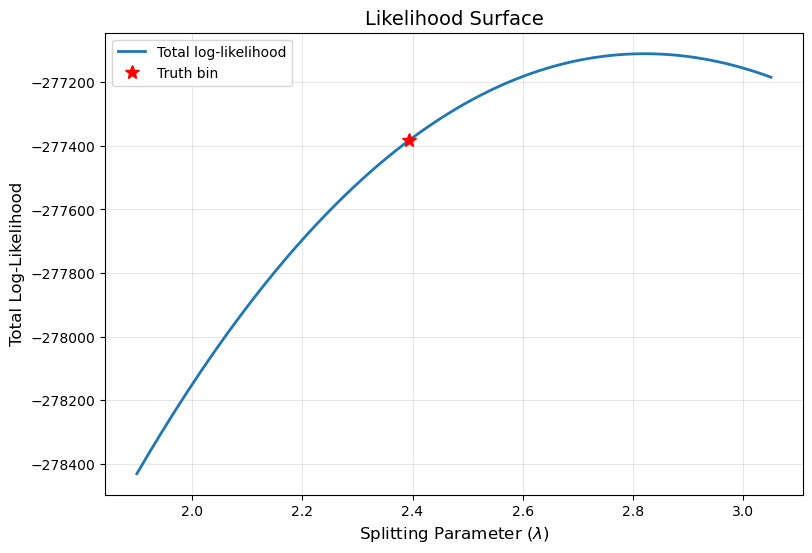

In [10]:
total_likelihood_surface = np.sum(likelihood_surface_array, axis=0)

valid = ~np.isnan(total_likelihood_surface)

fig, ax = plt.subplots(nrows=1, ncols=1)
fig.set_size_inches(9, 6)

ax.plot(lambda_vals[valid], total_likelihood_surface[valid], linewidth=2, label="Total log-likelihood")

if 0 <= truth_bin < len(lambda_vals) and valid[truth_bin]:
    ax.plot(lambda_vals[truth_bin], total_likelihood_surface[truth_bin], "r*", markersize=10, label="Truth bin")

ax.set_title("Likelihood Surface", size=14)
ax.set_xlabel("Splitting Parameter ($\\lambda$)", size=12)
ax.set_ylabel("Total Log-Likelihood", size=12)
ax.grid(True, alpha=0.3)
ax.legend()

In [11]:
mle_coords = np.unravel_index(np.argmax(total_likelihood_surface[~np.isnan(total_likelihood_surface)], axis=None),
                                  total_likelihood_surface.shape)[0]
print("MLE lambda: {:n}".format(lambda_vals[mle_coords]))

MLE lambda: 2.81846


This stage uses the best-fit $\lambda$ to generate a new reference sample and then reruns the Trellis scan on that sample.

The Trellis evaluation can take a long time, so it is usually better to launch it from the terminal rather than from the notebook.

## Generate a reference sample at the MLE

Use the best-fit $\lambda$ value to generate a new dataset and evaluate Trellis on the same scan range.

In [12]:
# This script generates the reference dataset for the inference examples. It should be run from the `examples/inference` directory.
# Run from terminal (or in this notebook with `!`):
# !python ../../scripts/make_ginkgo_dataset.py --output-dir ./data --qcd-rate {lambda_vals[mle_coords]} &> /dev/null

In [13]:
# Create a config file for the trellis grid 1D MLE example with the new dataset
with open('trellis_1D_MLE.config', 'w') as f:
    f.write(f"./data/ginkgo_10000_jets_no_cuts_lambda_{int(lambda_vals[mle_coords]*10)}_pt_min_30_jetp_400_with_perm" + '\n')
    f.write("--outdir /mnt/g/ginkgo/trellis/MLE" + '\n')

# Create a bash script to run the trellis grid 1D MLE example with the new dataset and config file
with open('run_trellis_grid_1D_MLE.sh', 'w') as f:
    f.write("#!/bin/bash" + '\n')
    f.write("python run_grid_1D_local.py --framework trellis --script ../../scripts/run_trellis_grid_1D.py --log-dir logs_trellis --config-file trellis_1D_MLE.config" + '\n')

In [14]:
# Run the trellis -> best run from the terminal
# !python run_grid_1D_local.py --framework trellis --script ../../scripts/run_trellis_grid_1D.py --log-dir logs_trellis --config-file trellis_1D_MLE.config

The final analysis step estimates partition-function ratios and uses them to correct the likelihood normalization.

## Reweight the likelihood surface

Estimate partition-function ratios from the MLE sample and use them to correct the total log-likelihood profile.

In [15]:
mle_trees = load_jets("data", "ginkgo_{}_jets_no_cuts_lambda_{}_pt_min_{}_jetp_400_with_perm".format(Njets,
                                                                                                    int(lambda_vals[mle_coords]*10),
                                                                                                    int(pt_cut_truth)))  # My test file

mle_likelihood_surface_array = get_likelihood_surface_array(lambda_min, lambda_max, n_lambda,
                                                        Njets=Njets,
                                                        pt_cut=pt_cut_truth,
                                                        likelihood="marginal",
                                                        datadir="/mnt/g/ginkgo/trellis/MLE")

100%|██████████| 150/150 [00:05<00:00, 27.40it/s]


In [16]:
bad_indices = []
for ix, entry in enumerate(mle_likelihood_surface_array):
    if np.any(np.isnan(entry)) or np.any(np.isinf(entry)):
         bad_indices.append(ix)

bad_indices = np.array(bad_indices)
print("Number of bad jets: {:n}".format(len(bad_indices)))
        
good_indices = np.arange(mle_likelihood_surface_array.shape[0])
for bad_ix in bad_indices:
    good_indices = good_indices[good_indices != bad_ix]


mle_likelihood_surface_array = mle_likelihood_surface_array[good_indices]
mle_trees = (np.array(mle_trees)[good_indices]).tolist()

Number of bad jets: 2


In [ ]:
def get_partition_ratio(loglikelihood_surface_array, lambda_bin, ref_bin=mle_coords):
    """Estimate Z(lambda_bin) / Z(ref_bin) from reweighted samples.

    The estimate uses samples drawn from the reference bin and averages
    exp(logL(lambda_bin) - logL(ref_bin)) across jets.
    """
    Njets = loglikelihood_surface_array.shape[0]

    log_ratio_per_sample = loglikelihood_surface_array[:, lambda_bin] - loglikelihood_surface_array[:, ref_bin]
    mean_ratio = np.mean(np.exp(log_ratio_per_sample))
    errors = np.std(np.exp(log_ratio_per_sample)) / np.sqrt(Njets)
    
    return mean_ratio, errors

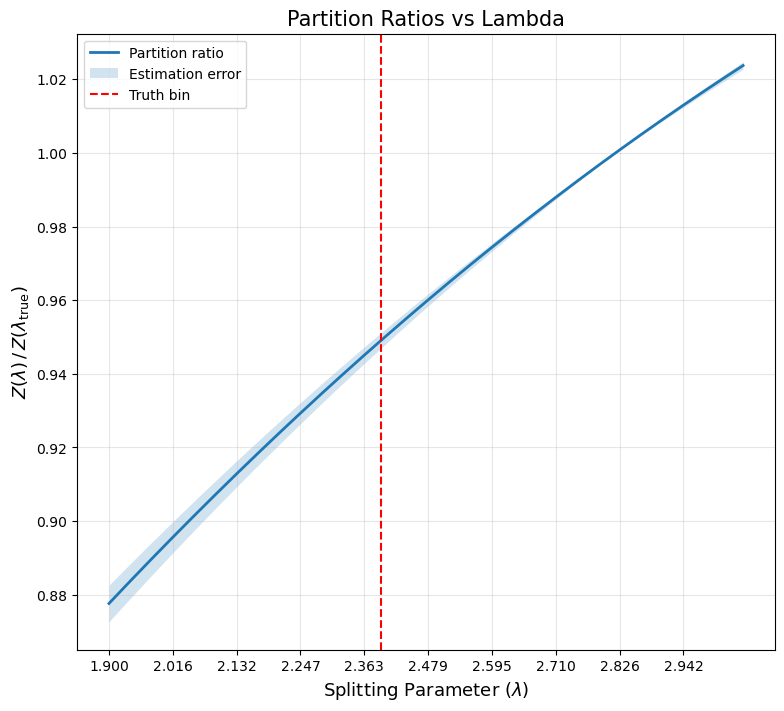

In [ ]:
partition_ratios, partition_errors = zip(*[get_partition_ratio(mle_likelihood_surface_array, lam_bin, mle_coords) for lam_bin in range(len(lambda_vals))])
partition_ratios = np.array(partition_ratios)
partition_errors = np.array(partition_errors)

fig, ax = plt.subplots(nrows=1, ncols=1)
fig.set_size_inches(9, 8)

finite = np.isfinite(partition_ratios) & np.isfinite(partition_errors)
x = lambda_vals[finite]
y = partition_ratios[finite]
yerr = partition_errors[finite]

ax.plot(x, y, linewidth=2, label="Partition ratio", color="C0")
ax.fill_between(x, y - yerr, y + yerr, color="C0", alpha=0.2, linewidth=0, label="Estimation error")

if 0 <= truth_bin < len(lambda_vals):
    ax.axvline(lambda_vals[truth_bin], color="red", linestyle="dashed", linewidth=1.5, label="Truth bin")

ax.grid(True, alpha=0.3)
ax.set_title("Partition Ratios vs $\\lambda$", size=15)
ax.set_xlabel("Splitting Parameter ($\\lambda$)", size=13)
ax.set_ylabel(r"$Z(\lambda)\,/\,Z(\lambda_{\mathrm{true}})$", size=13)
ax.set_xticks(lambda_vals[::15])
ax.legend()

In [38]:
adjusted_likelihood_surface = total_likelihood_surface - likelihood_surface_array.shape[0] * np.log(partition_ratios) # This will be shifted by a constant factor, but the dependency on lambda should be correct.

mle_coords = np.unravel_index(np.argmax(adjusted_likelihood_surface[~np.isnan(adjusted_likelihood_surface)], axis=None), adjusted_likelihood_surface.shape)[0]

<>:11: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:11: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_351905/668786784.py:11: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax.set_xlabel("Splitting Parameter ($\lambda$)", size=14)


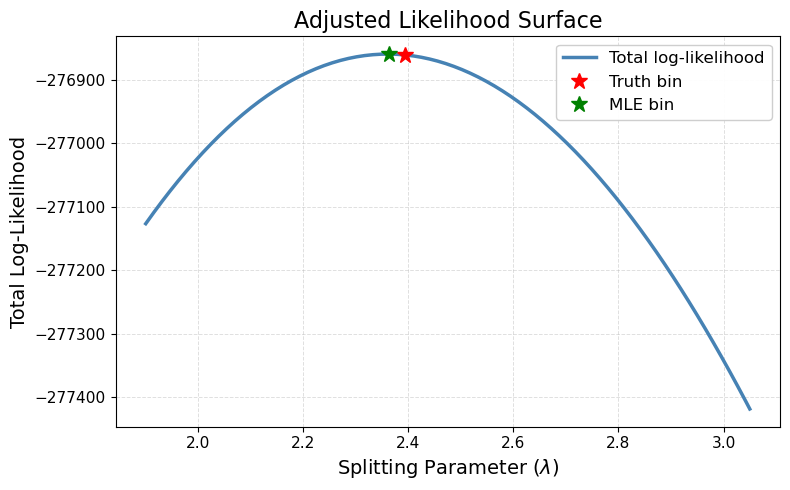

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))

ax.plot(lambda_vals, adjusted_likelihood_surface, linewidth=2.5, label="Total log-likelihood", color='steelblue')

if 0 <= truth_bin < len(lambda_vals) and valid[truth_bin]:
    ax.plot(lambda_vals[truth_bin], adjusted_likelihood_surface[truth_bin], "r*", markersize=12, label="Truth bin", zorder=5)

ax.plot(lambda_vals[mle_coords], adjusted_likelihood_surface[mle_coords], "g*", markersize=12, label="MLE bin", zorder=5)

ax.set_title("Adjusted Likelihood Surface", size=16)
ax.set_xlabel("Splitting Parameter ($\lambda$)", size=14)
ax.set_ylabel("Total Log-Likelihood", size=14)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.7)
ax.legend(fontsize=12, framealpha=0.95)

# Improve tick label appearance
ax.tick_params(labelsize=11)
fig.tight_layout()

In [41]:
## Repeat this process to update the MLE estimate and confidence intervals based on the adjusted likelihood surface.

# num_iterations = 5

# for iteration in range(num_iterations):
#     mle_coords = np.unravel_index(np.argmax(adjusted_likelihood_surface[~np.isnan(adjusted_likelihood_surface)], axis=None), adjusted_likelihood_surface.shape)[0]
#     print("Iteration {:d}: MLE bin = {:d}, lambda = {:.3f}".format(iteration+1, mle_coords, lambda_vals[mle_coords]))

#     partition_ratios = np.array([get_partition_ratio(likelihood_surface_array, lam_bin, mle_coords) for lam_bin in range(len(lambda_vals))])
#     adjusted_likelihood_surface = total_likelihood_surface - likelihood_surface_array.shape[0] * np.log(partition_ratios)

In [42]:
trellis_mle_jets = load_jets("/mnt/g/ginkgo/jets", "ginkgo_20000_jets_1D_jetp_400_lambda_{:n}_ptcut_{:n}_{}".format(
    int(lambda_vals[mle_coords]*1000),
    int(pt_cut_truth),
    mle_coords))

## Load the Trellis MLE sample

Fetch the sample generated at the current MLE estimate for downstream comparisons.

In [43]:
truth_num_leaves = np.array([len(x["leaves"]) for x in gt_trees])
truth_num_leaves_sigma = np.sqrt(np.histogram(truth_num_leaves, bins=np.arange(1,16)-0.5)[0]) / truth_num_leaves.size

trellis_num_leaves = np.array([len(x["leaves"]) for x in trellis_mle_jets])
trellis_num_leaves_sigma = np.sqrt(np.histogram(trellis_num_leaves, bins=np.arange(1,16)-0.5)[0]) / trellis_num_leaves.size

## Compare an observable

Compare the leaf-count distribution in the truth sample, the Trellis MLE sample, and the reweighted estimate.

In [44]:
Njets = len(gt_trees)
print(Njets)

p_n = np.zeros(20)
v_n = np.zeros(20)
for ix in range(Njets):
    w = 1*np.exp(likelihood_surface_array[ix, mle_coords] - likelihood_surface_array[ix, truth_bin])
    p_n[truth_num_leaves[ix]-1] += w
    v_n[truth_num_leaves[ix]-1] += w**2
    
p_n /= Njets
v_n /= Njets**2
sigma_n = np.sqrt(v_n)
w_tot = p_n.sum()

9996


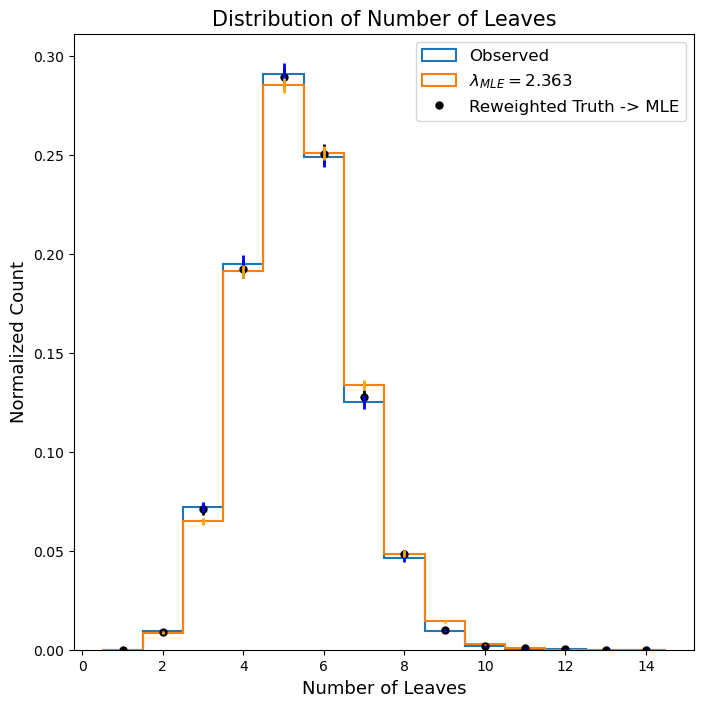

In [46]:
fig, ax = plt.subplots(nrows=1, ncols=1)
fig.set_size_inches(8,8)

truth_hist = ax.hist(truth_num_leaves, bins=np.arange(1,16)-0.5, histtype="step", linewidth=1.5, density=True, label="Observed")
trellis_hist = ax.hist(trellis_num_leaves, bins=np.arange(1,16)-0.5, histtype="step", linewidth=1.5,  density=True, label=rf"$\lambda_{{MLE}} = {lambda_vals[mle_coords]:.3f}$")
ax.plot(np.arange(1,15), p_n[:14] / w_tot, ".", markersize=10, color="black", label="Reweighted Truth -> MLE")
for i in range(14):
    ax.vlines(i+1,
              ymin=(p_n[i] - sigma_n[i])/w_tot,
              ymax=(p_n[i] + sigma_n[i])/w_tot,
              colors="black", linestyle="solid", linewidth=2)
    ax.vlines(i+1,
              ymin=truth_hist[0][i] - truth_num_leaves_sigma[i],
              ymax=truth_hist[0][i] + truth_num_leaves_sigma[i],
              colors="blue", linestyle="solid", linewidth=2)
    ax.vlines(i+1,
              ymin=trellis_hist[0][i] - trellis_num_leaves_sigma[i],
              ymax=trellis_hist[0][i] + trellis_num_leaves_sigma[i],
              colors="orange", linestyle="solid", linewidth=2)

ax.set_xlabel("Number of Leaves", size=13)
ax.set_ylabel("Normalized Count", size=13)
ax.set_title("Distribution of Number of Leaves", size=15)
ax.legend(fontsize="large")

## Final likelihood comparison

Show the original and reweighted likelihood surfaces on a common scale.

<>:21: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:21: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_351905/4214255544.py:21: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax.set_xlabel("Splitting Parameter ($\lambda$)", size=13)


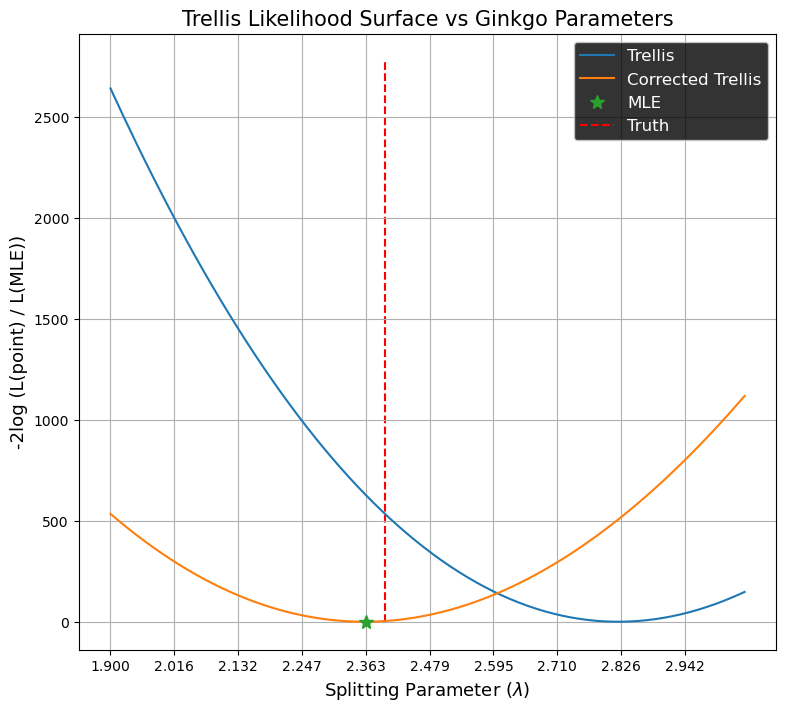

In [47]:
fig, ax = plt.subplots(nrows=1, ncols=1)
fig.set_size_inches(9,8)

Z = -2*(total_likelihood_surface-total_likelihood_surface.max())
Z2 = -2*(adjusted_likelihood_surface-adjusted_likelihood_surface.max())


ax.plot(lambda_vals, Z, label="Trellis")
ax.plot(lambda_vals, Z2, label="Corrected Trellis")
ax.plot(lambda_vals[mle_coords], Z2[mle_coords], "*", markersize=10, label="MLE", zorder=5)

y_min, y_max = ax.get_ylim()
    
ax.vlines((lambda_vals[truth_bin]+lambda_vals[truth_bin+1])/2, ymin=0, ymax=y_max, colors="red", linestyle="dashed",
           linewidth=1.5, label="Truth", zorder=0)

ax.legend(labelcolor="white", facecolor="black", fontsize="large")
ax.grid()

ax.set_title("Trellis Likelihood Surface vs Ginkgo Parameters", size=15)
ax.set_xlabel("Splitting Parameter ($\lambda$)", size=13)
ax.set_ylabel("-2log (L(point) / L(MLE))", size=13)
#ax.set_ylabel("logLikelihood", size=13)
ax.set_xticks(lambda_vals[::15]);